<a href="https://colab.research.google.com/github/VENOMDANGER2004/UCS-547-ACCELERATEDDS-/blob/main/AssignmentDS6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1

In [3]:
import cudf
import cupy as cp
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import urllib.request
import os

# 1. Load and Preprocess the Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
local_path = "adult.data"

if not os.path.exists(local_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, local_path)

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

# FIX: Add na_values=["?"] to handle missing data during the read step!
df_gpu = cudf.read_csv(local_path, names=columns, skipinitialspace=True, na_values=["?"])

# Now we can just safely drop the NAs without the replace function
df_gpu = df_gpu.dropna()

print(f"Dataset loaded. Shape: {df_gpu.shape}")
print("\nEligible features for GPU histogram binning (Continuous):")
print(["age", "fnlwgt", "capital-gain", "capital-loss", "hours-per-week"])

Dataset loaded. Shape: (32561, 15)

Eligible features for GPU histogram binning (Continuous):
['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']


CPU NumPy Time: 0.01098 s
GPU CuPy Time:  0.02275 s
Histogram Speedup: 0.48x


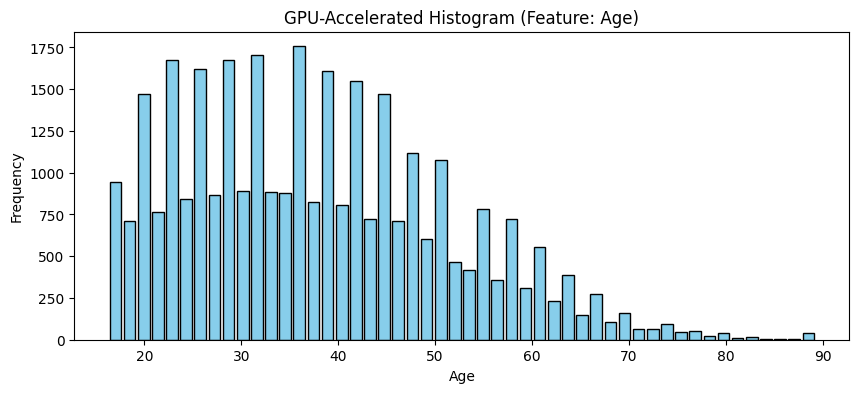

In [5]:
# Identify continuous features eligible for binning
continuous_features = ["age", "fnlwgt", "capital-gain", "capital-loss", "hours-per-week"]

# Use 'age' for the comparison
age_gpu = df_gpu['age'].to_cupy()
age_cpu = age_gpu.get() # Transfer to CPU for NumPy comparison

bins = 50

# --- CPU-Based NumPy Histogram ---
start_cpu = time.time()
hist_cpu, edges_cpu = np.histogram(age_cpu, bins=bins)
time_cpu = time.time() - start_cpu

# --- GPU-Based CuPy Histogram ---
# Warmup to initialize CUDA context
_ = cp.histogram(age_gpu[:10], bins=10)
cp.cuda.Stream.null.synchronize()

start_gpu = time.time()
hist_gpu, edges_gpu = cp.histogram(age_gpu, bins=bins)
cp.cuda.Stream.null.synchronize()
time_gpu = time.time() - start_gpu

# Print comparison results
print(f"CPU NumPy Time: {time_cpu:.5f} s")
print(f"GPU CuPy Time:  {time_gpu:.5f} s")
print(f"Histogram Speedup: {time_cpu / time_gpu:.2f}x")

# Visualize GPU results
plt.figure(figsize=(10, 4))
plt.bar(edges_gpu[:-1].get(), hist_gpu.get(), width=1.2, color='skyblue', edgecolor='black')
plt.title("GPU-Accelerated Histogram (Feature: Age)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

GPU Quantile Bin Edges (hours-per-week):
[ 1. 40. 40. 45. 99.]

Data distribution across bins (Illustrating Balance):
hours_bins
0     7763
2    15835
3     8963
Name: count, dtype: int64


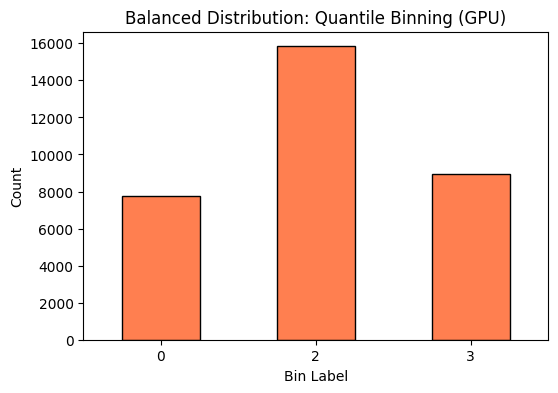

In [7]:
import cupy as cp

# 1. Compute quantiles on the GPU (quartiles: 0%, 25%, 50%, 75%, 100%)
num_bins = 4
quantiles = [i/num_bins for i in range(num_bins + 1)]
bin_edges = df_gpu['hours-per-week'].quantile(quantiles).to_cupy()

# 2. [span_2](start_span)Display bin edges[span_2](end_span)
print("GPU Quantile Bin Edges (hours-per-week):")
print(bin_edges)

# 3. [span_3](start_span)Assign labels using CuPy digitize (GPU-based labeling)[span_3](end_span)
hours_gpu = df_gpu['hours-per-week'].to_cupy()
df_gpu['hours_bins'] = cp.digitize(hours_gpu, bin_edges[1:-1])

# 4. [span_4](start_span)Illustrate balanced data distribution[span_4](end_span)
bin_counts = df_gpu['hours_bins'].value_counts().sort_index().to_pandas()
print("\nData distribution across bins (Illustrating Balance):")
print(bin_counts)

# 5. Visualize the balanced distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
bin_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Balanced Distribution: Quantile Binning (GPU)")
plt.xlabel("Bin Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [9]:
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.preprocessing import LabelEncoder
from cuml.model_selection import train_test_split
from cuml.metrics import accuracy_score
import xgboost as xgb

# Preprocess remaining categorical features
categorical_cols = ["workclass", "education", "marital-status", "occupation",
                    "relationship", "race", "sex", "native-country", "income"]

for col in categorical_cols:
    df_gpu[col] = LabelEncoder().fit_transform(df_gpu[col])

# Prepare data for training
X = df_gpu.drop(["income", "hours_bins"], axis=1).astype('float32')
y = df_gpu["income"].astype('int32')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -[span_6](start_span)-- XGBoost with tree_method='gpu_hist' ---[span_6](end_span)
xgb_model = xgb.XGBClassifier(tree_method='hist', device='cuda',n_estimators=100)
start_xgb = time.time()
xgb_model.fit(X_train.to_pandas(), y_train.to_pandas())
time_xgb = time.time() - start_xgb
xgb_acc = accuracy_score(y_test, xgb_model.predict(X_test.to_pandas()))

# -[span_7](start_span)-- cuML Random Forest (GPU) ---[span_7](end_span)
cuml_rf = cuRF(n_estimators=100)
start_cuml = time.time()
cuml_rf.fit(X_train, y_train)
time_cuml = time.time() - start_cuml
cuml_acc = accuracy_score(y_test, cuml_rf.predict(X_test))

# -[span_8](start_span)-- Results Table ---[span_8](end_span)
print(f"{'Model':<25} | {'Training Time (s)':<20} | {'Accuracy':<10}")
print("-" * 60)
print(f"{'XGBoost (gpu_hist)':<25} | {time_xgb:<20.4f} | {xgb_acc:.4f}")
print(f"{'cuML Random Forest':<25} | {time_cuml:<20.4f} | {cuml_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:56:14] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Model                     | Training Time (s)    | Accuracy  
------------------------------------------------------------
XGBoost (gpu_hist)        | 0.5790               | 0.8743
cuML Random Forest        | 0.7276               | 0.8641


Q2

--- Performance Summary ---
CPU Accuracy: 0.9649 | GPU Accuracy: 0.9649
GPU Speedup: 1.67x



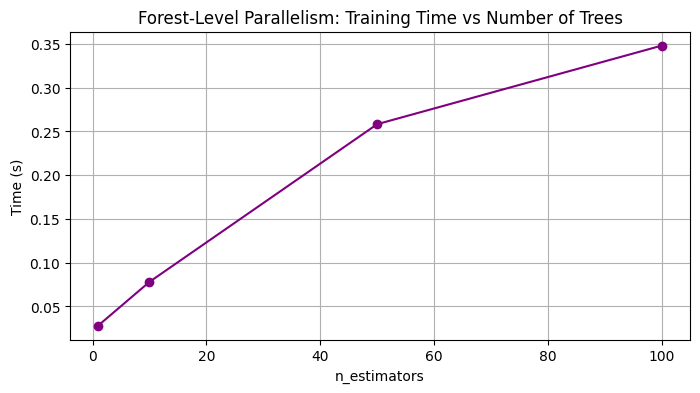

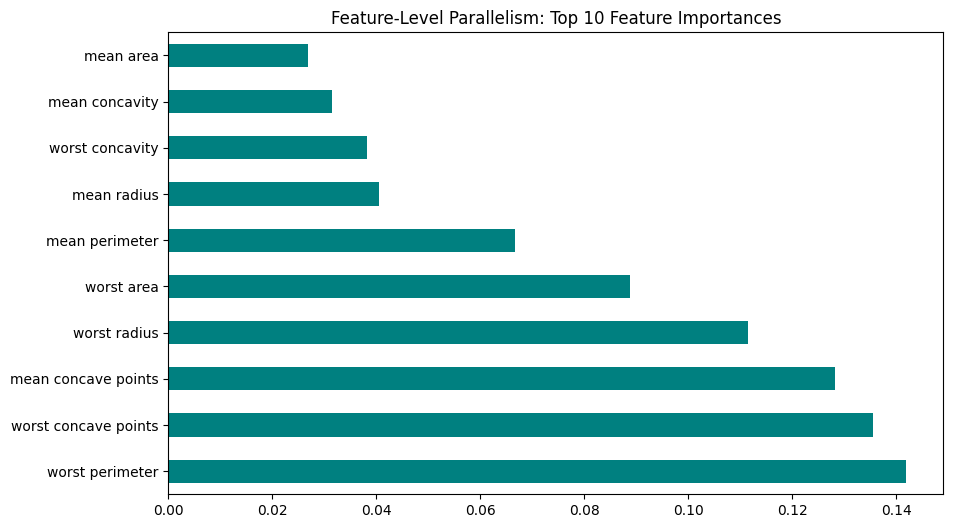

/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


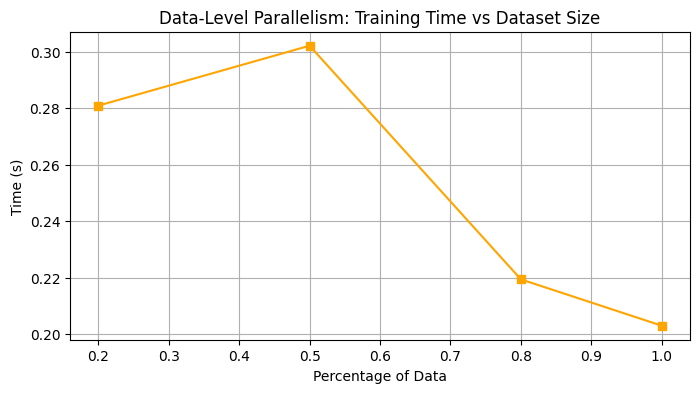

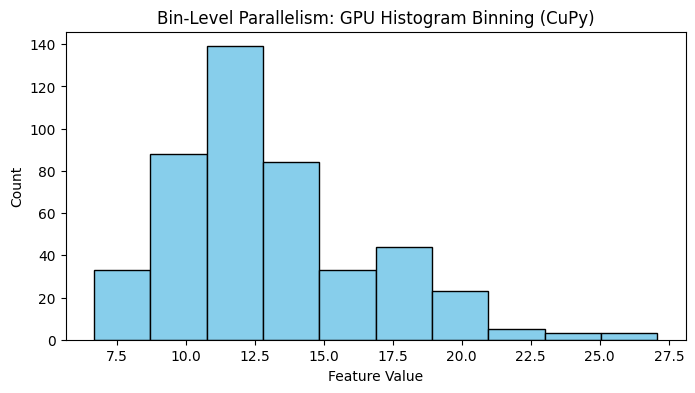


Final Performance Comparison Table:
         Metric CPU (scikit-learn) GPU (RAPIDS cuML)
  Training Time            0.4997s           0.2986s
Prediction Time            0.0346s           0.0097s
       Accuracy             0.9649            0.9649


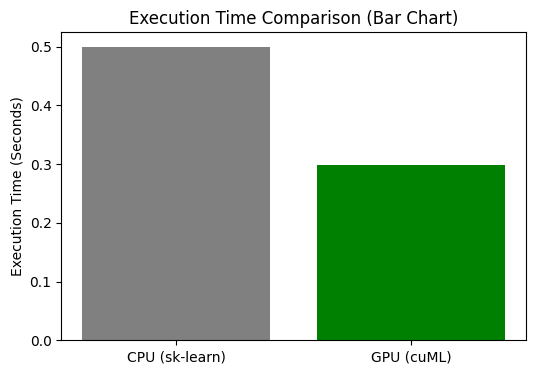

In [12]:
import time
import cudf
import cupy as cp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split as sk_split
from sklearn.ensemble import RandomForestClassifier as skRF
from cuml.ensemble import RandomForestClassifier as cuRF

# 1. [span_2](start_span)Data Preparation[span_2](end_span)
# [span_3](start_span)Load the dataset using load_breast_cancer()[span_3](end_span)
data = load_breast_cancer()
X, y = data.data.astype('float32'), data.target.astype('int32')

# [span_4](start_span)Split it into training and testing sets[span_4](end_span)
X_train, X_test, y_train, y_test = sk_split(X, y, test_size=0.2, random_state=42)

# [span_5](start_span)Convert the dataset into cuDF format for GPU processing[span_5](end_span)
X_train_gpu = cudf.DataFrame(X_train)
y_train_gpu = cudf.Series(y_train)
X_test_gpu = cudf.DataFrame(X_test)

# 2. [span_6](start_span)CPU Implementation[span_6](end_span)
# [span_7](start_span)Train a Random Forest model using scikit-learn[span_7](end_span)
cpu_rf = skRF(n_estimators=100, random_state=42)
start_cpu = time.time()
cpu_rf.fit(X_train, y_train)
cpu_train_time = time.time() - start_cpu

# [span_8](start_span)Record training time, prediction time, and accuracy[span_8](end_span)
start_pred = time.time()
cpu_preds = cpu_rf.predict(X_test)
cpu_pred_time = time.time() - start_pred
cpu_acc = cpu_rf.score(X_test, y_test)

# 3. [span_9](start_span)GPU Implementation[span_9](end_span)
# [span_10](start_span)Train a Random Forest model using RAPIDS cuML[span_10](end_span)
gpu_rf = cuRF(n_estimators=100, random_state=42)
start_gpu = time.time()
gpu_rf.fit(X_train_gpu, y_train_gpu)
gpu_train_time = time.time() - start_gpu

# [span_11](start_span)Measure training time, prediction time, and accuracy[span_11](end_span)
start_pred = time.time()
gpu_preds = gpu_rf.predict(X_test_gpu)
gpu_pred_time = time.time() - start_pred
gpu_acc = gpu_rf.score(X_test_gpu, y_test)

# [span_12](start_span)Compute GPU speedup over the CPU[span_12](end_span)
speedup = cpu_train_time / gpu_train_time

print(f"--- Performance Summary ---")
print(f"CPU Accuracy: {cpu_acc:.4f} | GPU Accuracy: {gpu_acc:.4f}")
print(f"GPU Speedup: {speedup:.2f}x\n")

# 4. [span_13](start_span)Visualization of Parallelism[span_13](end_span)

# [span_14](start_span)Forest-Level Parallelism: Plot training time vs number of trees (n_estimators = 1, 10, 50, 100)[span_14](end_span)
tree_counts = [1, 10, 50, 100]
forest_times = []
for n in tree_counts:
    model = cuRF(n_estimators=n)
    start = time.time()
    model.fit(X_train_gpu, y_train_gpu)
    forest_times.append(time.time() - start)

plt.figure(figsize=(8, 4))
plt.plot(tree_counts, forest_times, marker='o', color='purple')
plt.title("Forest-Level Parallelism: Training Time vs Number of Trees")
plt.xlabel("n_estimators")
plt.ylabel("Time (s)")
plt.grid(True)
plt.show()

# [span_15](start_span)Feature-Level Parallelism: Plot feature importance from the trained model[span_15](end_span)
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(gpu_rf.feature_importances_, index=data.feature_names)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Feature-Level Parallelism: Top 10 Feature Importances")
plt.show()

# [span_16](start_span)Data-Level Parallelism: Measure training time for varying dataset sizes[span_16](end_span)
sizes = [0.2, 0.5, 0.8, 1.0]
data_times = []
for s in sizes:
    idx = int(len(X_train_gpu) * s)
    subset_X = X_train_gpu[:idx]
    subset_y = y_train_gpu[:idx]
    start = time.time()
    cuRF(n_estimators=50).fit(subset_X, subset_y)
    data_times.append(time.time() - start)

plt.figure(figsize=(8, 4))
plt.plot(sizes, data_times, marker='s', color='orange')
plt.title("Data-Level Parallelism: Training Time vs Dataset Size")
plt.xlabel("Percentage of Data")
plt.ylabel("Time (s)")
plt.grid(True)
plt.show()

# [span_17](start_span)Bin-Level Parallelism: Demonstrate GPU histogram binning using CuPy[span_17](end_span)
feature_data = X_train_gpu.iloc[:, 0].to_cupy()
hist_gpu, bin_edges = cp.histogram(feature_data, bins=10)

plt.figure(figsize=(8, 4))
plt.bar(bin_edges[:-1].get(), hist_gpu.get(), width=np.diff(bin_edges.get()), color='skyblue', edgecolor='black')
plt.title("Bin-Level Parallelism: GPU Histogram Binning (CuPy)")
plt.xlabel("Feature Value")
plt.ylabel("Count")
plt.show()

# 5. [span_18](start_span)Performance Comparison[span_18](end_span)
# [span_19](start_span)Create a table comparing CPU and GPU results[span_19](end_span)
comparison_df = pd.DataFrame({
    "Metric": ["Training Time", "Prediction Time", "Accuracy"],
    "CPU (scikit-learn)": [f"{cpu_train_time:.4f}s", f"{cpu_pred_time:.4f}s", f"{cpu_acc:.4f}"],
    "GPU (RAPIDS cuML)": [f"{gpu_train_time:.4f}s", f"{gpu_pred_time:.4f}s", f"{gpu_acc:.4f}"]
})

print("\nFinal Performance Comparison Table:")
print(comparison_df.to_string(index=False))

# [span_20](start_span)Visualize execution time using bar charts[span_20](end_span)
plt.figure(figsize=(6, 4))
plt.bar(['CPU (sk-learn)', 'GPU (cuML)'], [cpu_train_time, gpu_train_time], color=['grey', 'green'])
plt.title("Execution Time Comparison (Bar Chart)")
plt.ylabel("Execution Time (Seconds)")
plt.show()